In [484]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score, classification_report,ConfusionMatrixDisplay,confusion_matrix


In [485]:
churnData=pd.read_excel("churn_dataset.xlsx")
churnData.head()

,Age,Tenure,Sex,Churn
0,56,8,Male,No
1,46,63,Female,No
2,32,11,Female,No
3,60,8,Male,No
4,25,35,Male,No


In [486]:
churnData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Age     100 non-null    int64 
 1   Tenure  100 non-null    int64 
 2   Sex     100 non-null    object
 3   Churn   100 non-null    object
dtypes: int64(2), object(2)
memory usage: 3.3+ KB


In [487]:
churnData['Sex'] = churnData['Sex'].map({'Male': 0, 'Female': 1})

In [488]:
churnData['Churn'] = churnData['Churn'].map({'No': 0, 'Yes': 1})

In [489]:
churnData

,Age,Tenure,Sex,Churn
0,56,8,0,0
1,46,63,1,0
2,32,11,1,0
3,60,8,0,0
4,25,35,0,0
...,...,...,...,...
95,24,38,1,0
96,26,24,0,0
97,41,69,1,1
98,18,70,0,0


In [490]:
churnData.isna().sum()

,0
Age,0
Tenure,0
Sex,0
Churn,0


In [491]:
churnData.drop_duplicates(inplace=True)

In [492]:
print(churnData['Churn'].value_counts())
print(churnData['Churn'].value_counts(normalize=True))

Churn
0    75
1    25
Name: count, dtype: int64
Churn
0    0.75
1    0.25
Name: proportion, dtype: float64


In [493]:
X = churnData.drop(columns=['Churn'])
Y = churnData['Churn']

In [494]:
X.shape

(100, 3)

In [495]:
X.head()


,Age,Tenure,Sex
0,56,8,0
1,46,63,1
2,32,11,1
3,60,8,0
4,25,35,0


In [496]:
Y.shape

(100,)

In [497]:
X.corr()

,Age,Tenure,Sex
Age,1.000000,0.017414,0.000692
Tenure,0.017414,1.000000,0.127916
Sex,0.000692,0.127916,1.000000


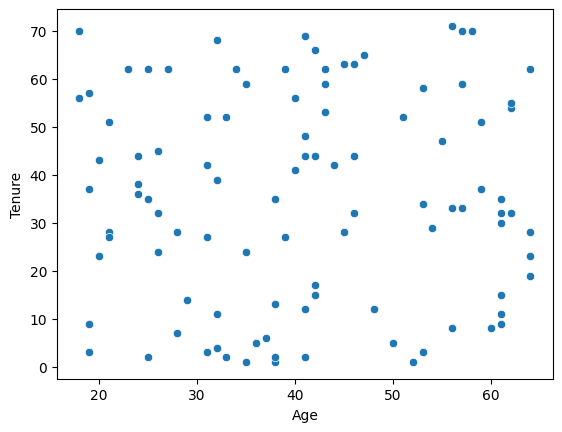

In [498]:
import seaborn as sns

sns.scatterplot(y= X.Tenure, x= X.Age);

In [499]:
from sklearn.preprocessing import StandardScaler
stc = StandardScaler()
X[['Age', 'Tenure']] = stc.fit_transform(X[['Age', 'Tenure']])


In [500]:
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler(feature_range=(0,1))
# X_scaled_MMS = scaler.fit_transform(X)
# print(X_scaled_MMS)

In [501]:
X

,Age,Tenure,Sex
0,1.086153,-1.254364,0
1,0.367798,1.297986,1
2,-0.637899,-1.115145,1
3,1.373495,-1.254364,0
4,-1.140748,-0.001392,0
...,...,...,...
95,-1.212584,0.137827,1
96,-1.068913,-0.511862,0
97,0.008620,1.576425,1
98,-1.643597,1.622831,0


In [502]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     100 non-null    float64
 1   Tenure  100 non-null    float64
 2   Sex     100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [503]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100.0,-1.998401e-16,1.005038,-1.643597,-0.745653,0.008620,0.888605,1.660837
Tenure,100.0,-8.215650e-17,1.005038,-1.579209,-0.941121,-0.001392,0.891931,1.669238
Sex,100.0,5.400000e-01,0.500908,0.000000,0.000000,1.000000,1.000000,1.000000


In [504]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42,shuffle=True)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (70, 3)
Test size: (30, 3)


In [505]:
model_gnb = GaussianNB()
model_gnb.fit(X_train, y_train)


GaussianNB()

In [506]:
y_pred = model_gnb.predict(X_test)

In [507]:
print("Accuracy:  ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("F1 Score:  ", f1_score(y_test, y_pred))
print("Recall:    ", recall_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy:   0.8
Precision:  0.0
F1 Score:   0.0
Recall:     0.0
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        24
           1       0.00      0.00      0.00         6

    accuracy                           0.80        30
   macro avg       0.40      0.50      0.44        30
weighted avg       0.64      0.80      0.71        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

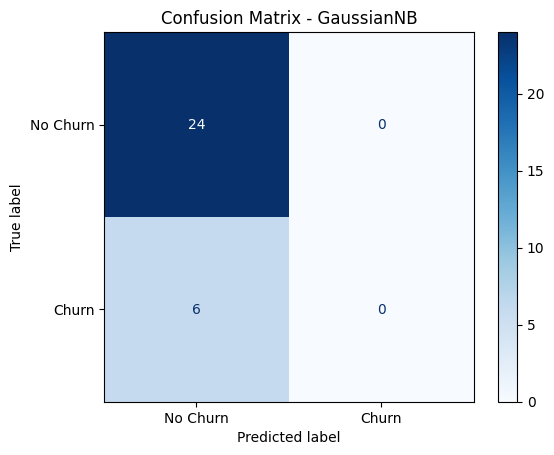

In [508]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - GaussianNB')
plt.show()

In [509]:
import joblib

joblib.dump(model_gnb, "churn_model.pkl")
joblib.dump(stc, "scaler.pkl")

['scaler.pkl']